 Data Exploration and data preprocessing:

 Load the dataset and perform exploratory data analysis (EDA).


In [ ]:
# Loading the dataset
import pandas as pd

df=pd.read_csv('/content/Titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Examine the features, their types, and summary statistics.

In [ ]:
# data types of a dataset
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

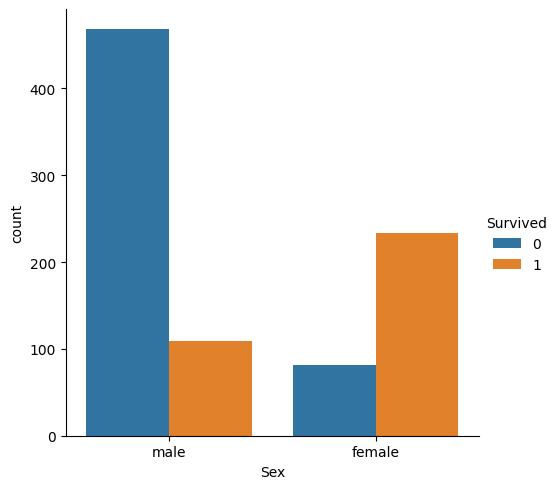

In [ ]:
# survived vs sex
import seaborn as sns
sns.catplot(data=df,x='Sex',hue='Survived',kind='count')

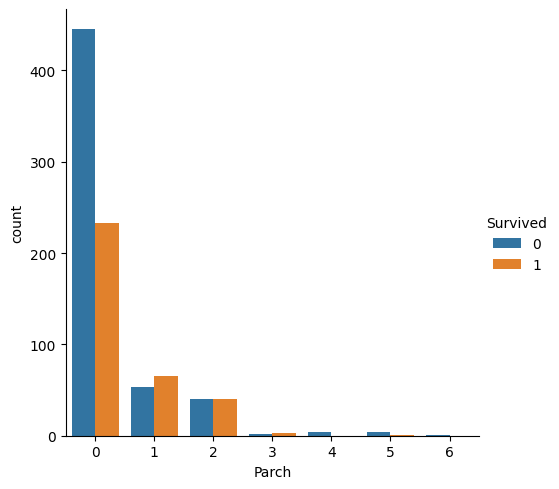

In [ ]:
#survived vs parch
sns.catplot(data=df,x='Parch',hue='Survived',kind='count')

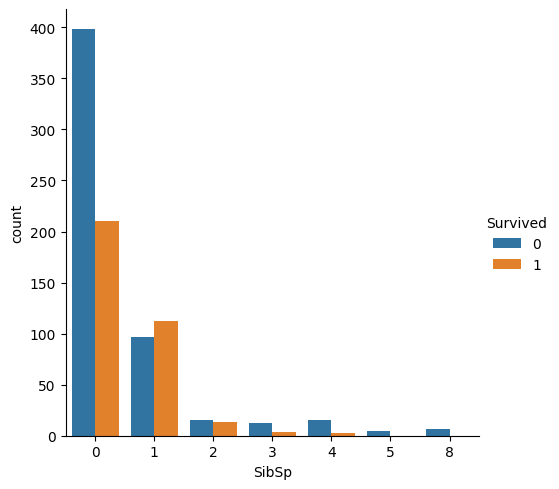

In [ ]:
#survived vs sibsp
sns.catplot(data=df,x='SibSp',hue='Survived',kind='count')

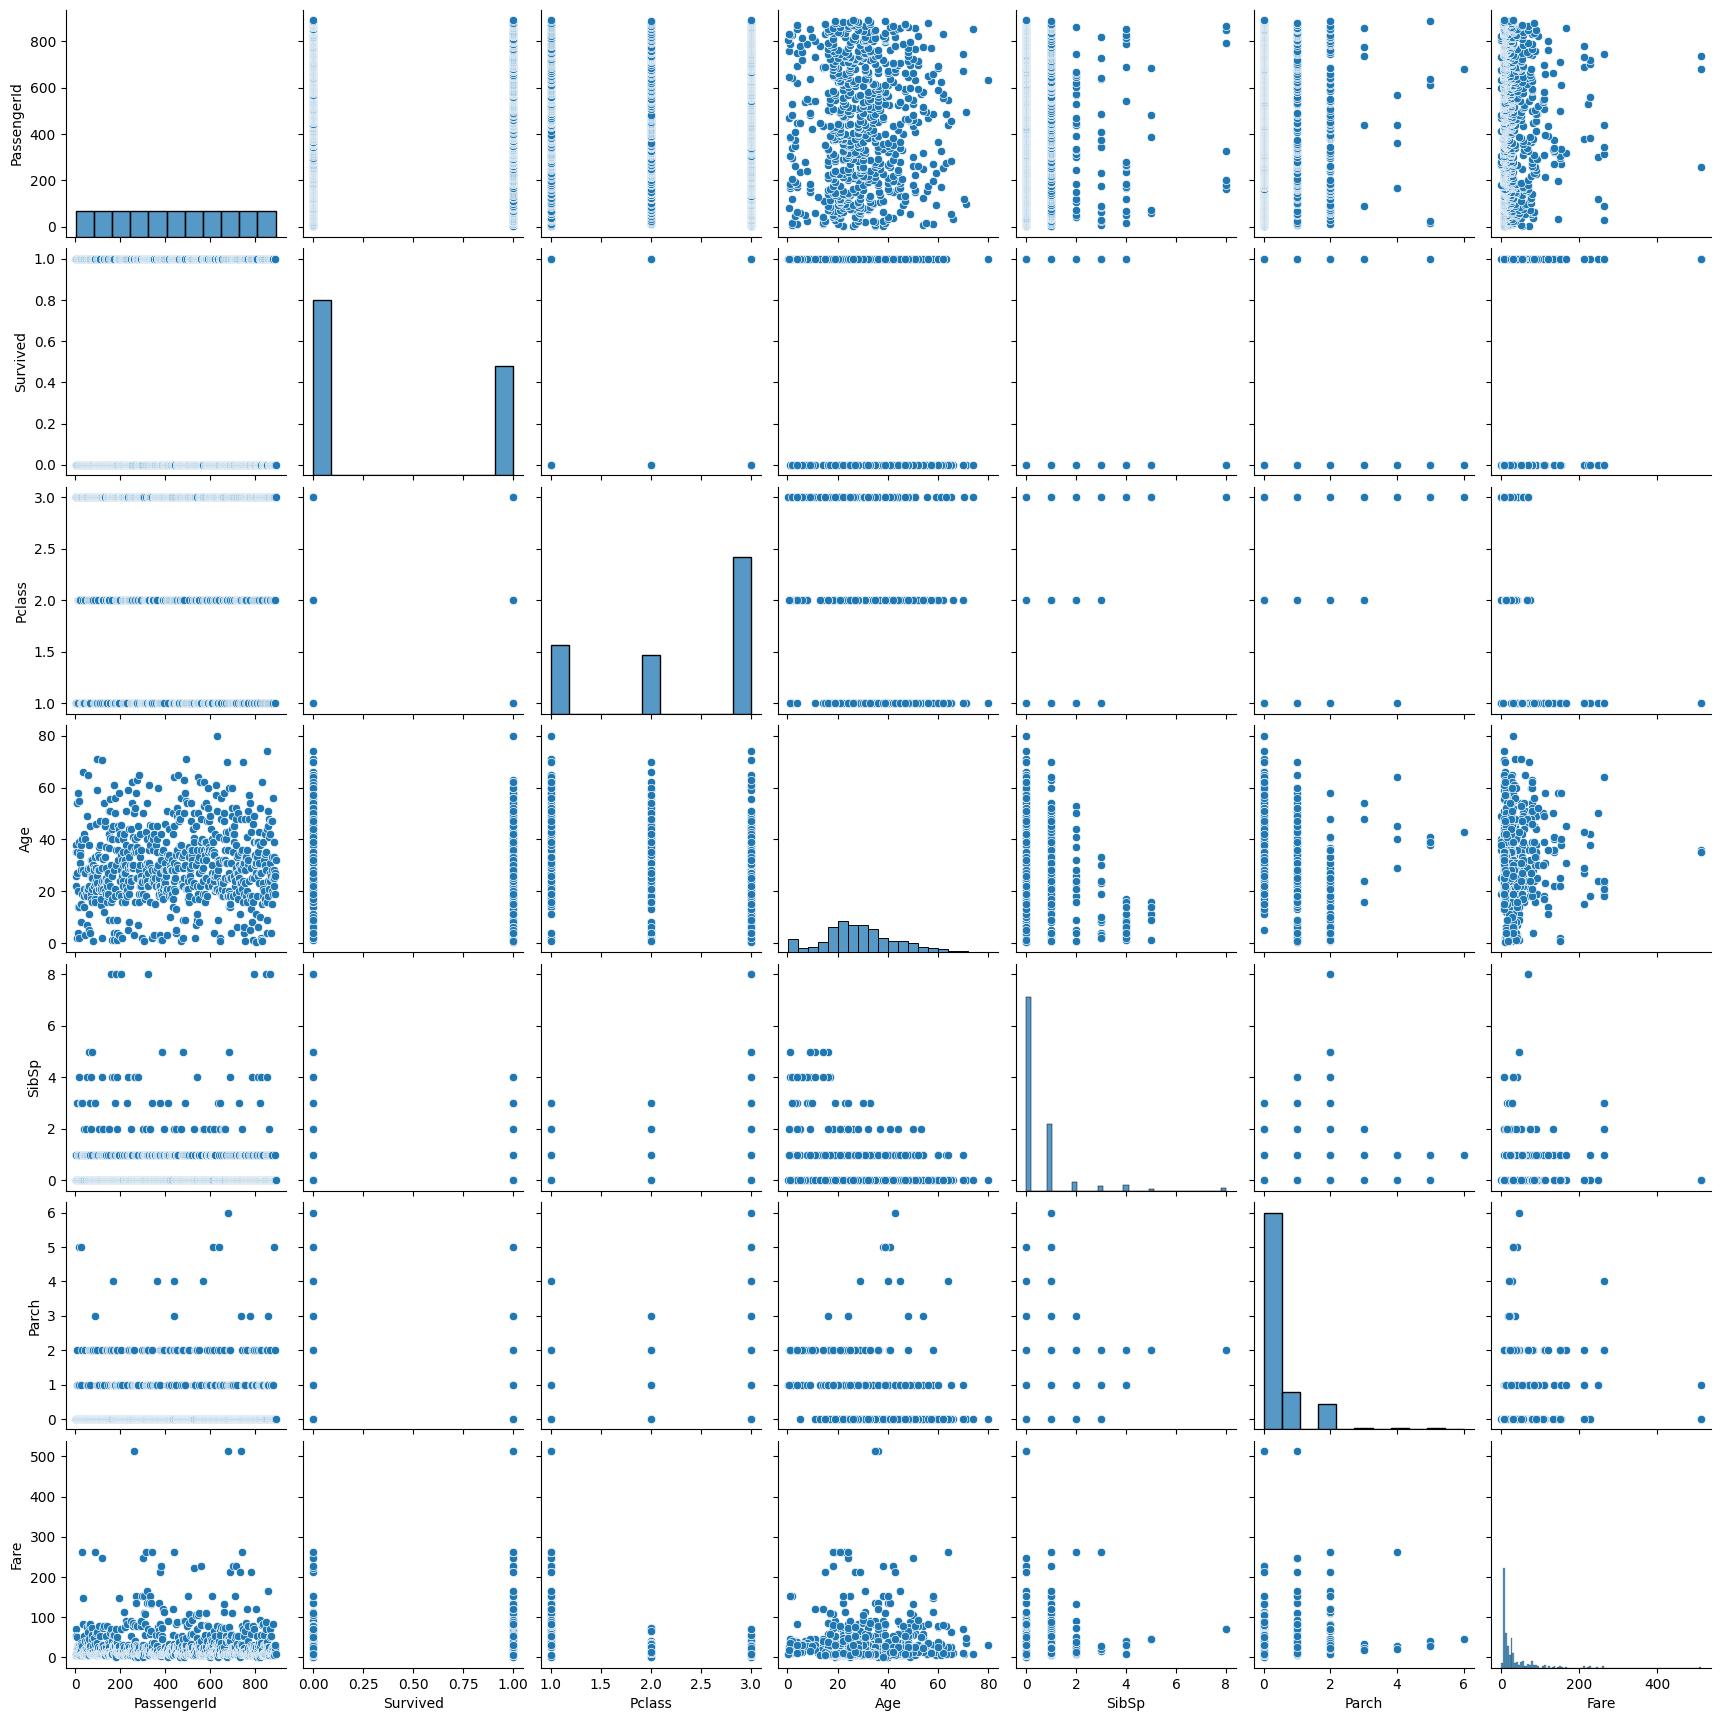

In [ ]:
sns.pairplot(data=df)

Handle missing values (e.g., imputation).

In [ ]:
# EDA

# check for any null values
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.shape

(891, 12)

In [ ]:
#  cabin has more null values.It indicates it is less important
# Passenger id ,name,ticket,cabin are the irrelevent columns
# dropping

df=df.drop(columns=['PassengerId','Name','Ticket','Cabin'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
#  there is missing values
# Age is numerical
mean_age=df['Age'].mean()
#  embarked are categorical
mode_embarked=df['Embarked'].mode()

In [ ]:
df.fillna({'Age':mean_age,'Embarked':mode_embarked[0]},inplace=True)
df['Age'].max()

80.0

In [ ]:
# checking for duplicates
df.duplicated().any()

True

<Axes: >

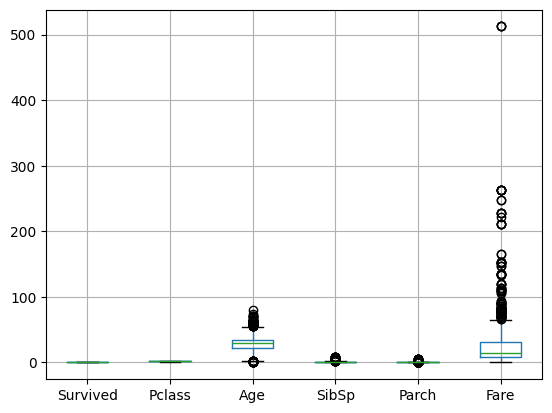

In [ ]:
# outliers detection
df.boxplot()

In [ ]:
# capping
def outlier_capping(df,column):
  Q1=df[column].quantile(0.25)
  Q3=df[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  df[column]=df[column].apply(lambda x: upper_bound if x>upper_bound else x)


outlier_capping(df,column='Fare')

Encode categorical variables

In [ ]:
# Labeling the categorical columns
df=pd.get_dummies(df,dtype='int')
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,65.6344,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


<Axes: >

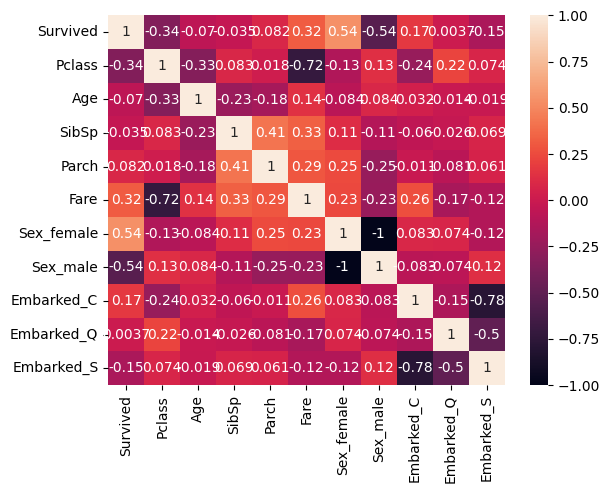

In [ ]:
#correlation

corr=df.corr()

import seaborn as sns
sns.heatmap(corr,annot=True)

In [ ]:
# target is survived
target=df['Survived']

# The rest all are feature
features=df.drop(columns='Survived')
features.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,65.6344,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1


Model Building:

a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

b. Train the model using the training data.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(712, 10)
(712,)
(179, 10)
(179,)


In [ ]:
log_model=LogisticRegression()

In [ ]:
log_model.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred_train=log_model.predict(x_train)
accuracy_score(y_train,y_pred_train)

0.7921348314606742

Model Evaluation:

a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

Visualize the ROC curve.


In [ ]:
df_test=pd.read_csv('/content/Titanic_test.csv')

In [ ]:
#Eda
df_test.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [ ]:
df_test=df_test.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [ ]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [ ]:
# imputation
mean_age=df['Age'].mean()
mean_fare=df['Fare'].mean()
df_test.fillna({'Age':mean_age,'Fare':mean_fare},inplace=True)

In [ ]:
# labeling
df_test=pd.get_dummies(df_test,dtype='int')


In [ ]:
df_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,0,1,0,1,0
1,3,47.0,1,0,7.0000,1,0,0,0,1
2,2,62.0,0,0,9.6875,0,1,0,1,0
3,3,27.0,0,0,8.6625,0,1,0,0,1
4,3,22.0,1,1,12.2875,1,0,0,0,1


In [ ]:
# prediction
y_pred=log_model.predict(df_test)
y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,

In [ ]:
# accuracy
y_pred_test=log_model.predict(x_test)
accuracy_score(y_test,y_pred_test)

0.7988826815642458

In [ ]:
# precision,recall,F1-score
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       104
           1       0.79      0.71      0.75        75

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
# roc-auc score
from sklearn.metrics import roc_auc_score

In [ ]:
pred_proba=log_model.predict_proba(x_test)
sigmoid=pred_proba[:,1]

In [ ]:
roc_auc_score(y_test,sigmoid)

0.8521153846153846

In [ ]:
# roc curve
from sklearn.metrics import roc_curve
fpr,tpr,thr=roc_curve(y_test,sigmoid)

Text(0, 0.5, 'tpr')

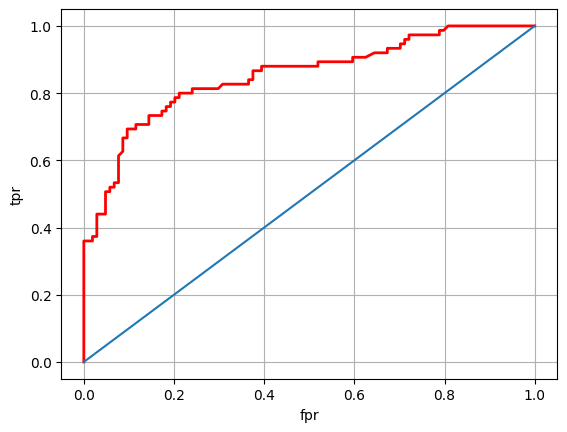

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,color='red',linewidth=2)
plt.plot([0,1])
plt.grid()
plt.xlabel('fpr')
plt.ylabel('tpr')

Interpretation:

a. Interpret the coefficients of the logistic regression model.

b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [ ]:
coefficients = pd.DataFrame({"Feature": x_train.columns, "Coefficient": log_model.coef_[0]})
coefficients

,Feature,Coefficient
0,Pclass,-0.790113
1,Age,-0.038493
2,SibSp,-0.367977
3,Parch,-0.212861
4,Fare,0.019125
5,Sex_female,1.946771
6,Sex_male,-0.734536
7,Embarked_C,0.550126
8,Embarked_Q,0.429545
9,Embarked_S,0.232563


In [ ]:
'''
Where the coefficients are negative these people have low survival probability.
Positive cofficients has higher level of survival probability.
'''

'\nWhere the coefficients are negative these people have low survival probability.\nPositive cofficients has higher level of survival probability.\n'

In [ ]:
'''
Significant of features:
Pclass	-0.790113
	Age	-0.038493
	SibSp	-0.367977
	Parch	-0.212861
	Sex_male	-0.734536
These features has the lower survival rate.


Fare	0.019125
	Sex_female	1.946771
  Embarked_C	0.550126
	Embarked_Q	0.429545
	Embarked_S	0.232563
  These features has the higher survival rate.
  '''


'\nSignificant of features:\nPclass\t-0.790113\n\tAge\t-0.038493\n\tSibSp\t-0.367977\n\tParch\t-0.212861\n\tSex_male\t-0.734536\nThese features has the lower survival rate.\n\n\nFare\t0.019125\n\tSex_female\t1.946771\n  Embarked_C\t0.550126\n\tEmbarked_Q\t0.429545\n\tEmbarked_S\t0.232563\n  These features has the higher survival rate.\n  '

Deployment with Streamlit:

In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.


In [56]:
import pickle
file='log25.pkl'
pickle.dump(log_model,open(file,'wb'))

In [57]:
# install streamlit
!pip install -q streamlit

In [58]:
# insatll localtunnel
!npm install -g localtunnel -U

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 4s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [59]:
#model_dep.py
%%writefile Model_dep.py
import pandas as pd
import streamlit as st
import pickle
import warnings
warnings.filterwarnings('ignore')
model=pickle.load(open('log25.pkl','rb'))
def user_input_parameters():
  Pclass=st.sidebar.selectbox('Pclass,class1=1,class2=2,class3=3',[1,2,3])
  Age=st.sidebar.slider('Age',0,100)
  SibSp	=st.sidebar.slider('SibSp',0,10)
  Parch=st.sidebar.slider('Parch',0,10)
  Sex_female=st.sidebar.selectbox('Sex_female,Yes=1,No=0',[0,1])
  Sex_male=st.sidebar.selectbox('Sex_male,Yes=1,No=0',[0,1])
  Embarked_C=st.sidebar.selectbox('Embarked_C,Yes=1,No=0',[0,1])
  Embarked_Q=st.sidebar.selectbox('Embarked_Q,Yes=1,No=0',[0,1])
  Embarked_S=st.sidebar.selectbox('Embarked_S,Yes=1,No=0',[0,1])
  Fare=st.sidebar.number_input('Fare')
  data={'Pclass':Pclass,'Age':Age,'SibSp':SibSp,'Parch':Parch,'Fare':Fare,'Sex_female':Sex_female,
        'Sex_male':Sex_male,'Embarked_C':Embarked_C,'Embarked_Q':Embarked_Q,'Embarked_S':Embarked_S}
  features=pd.DataFrame(data,index=[0])
  return features

df=user_input_parameters()
pred_proba=model.predict_proba(df)
predicted=model.predict(df)
st.subheader('Predicted Result')
st.write('Yes' if pred_proba[0][1]>=0.5 else 'No')
st.subheader('Predicted_Proba')
st.write(pred_proba)

Writing Model_dep.py


In [60]:
!wget -q -O - ipv4.icanhazip.com

35.221.147.69


In [61]:
!streamlit run Model_dep.py & npx localtunnel --port 8501



⠙⠹⠸
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.147.69:8501

⠼⠴your url is: https://some-jeans-film.loca.lt
  Stopping...
^C
